# Process Mining Analysis of Market Intel

This notebook uses Process Mining through the pm4py tool to mine the flow of the market intelligence agent. It analyses the event log of that agent, discovers its process model, and uses conformance checks to compare that process model to the intended flow. 


## About the Agent

The market intelligence agent is a short-running agent that produces a market intelligence report about a given company by combiming SEC filings, stock information, and news. The agent is built as a graph. 

The following BPMN diagram describes the process that the agent uses: 
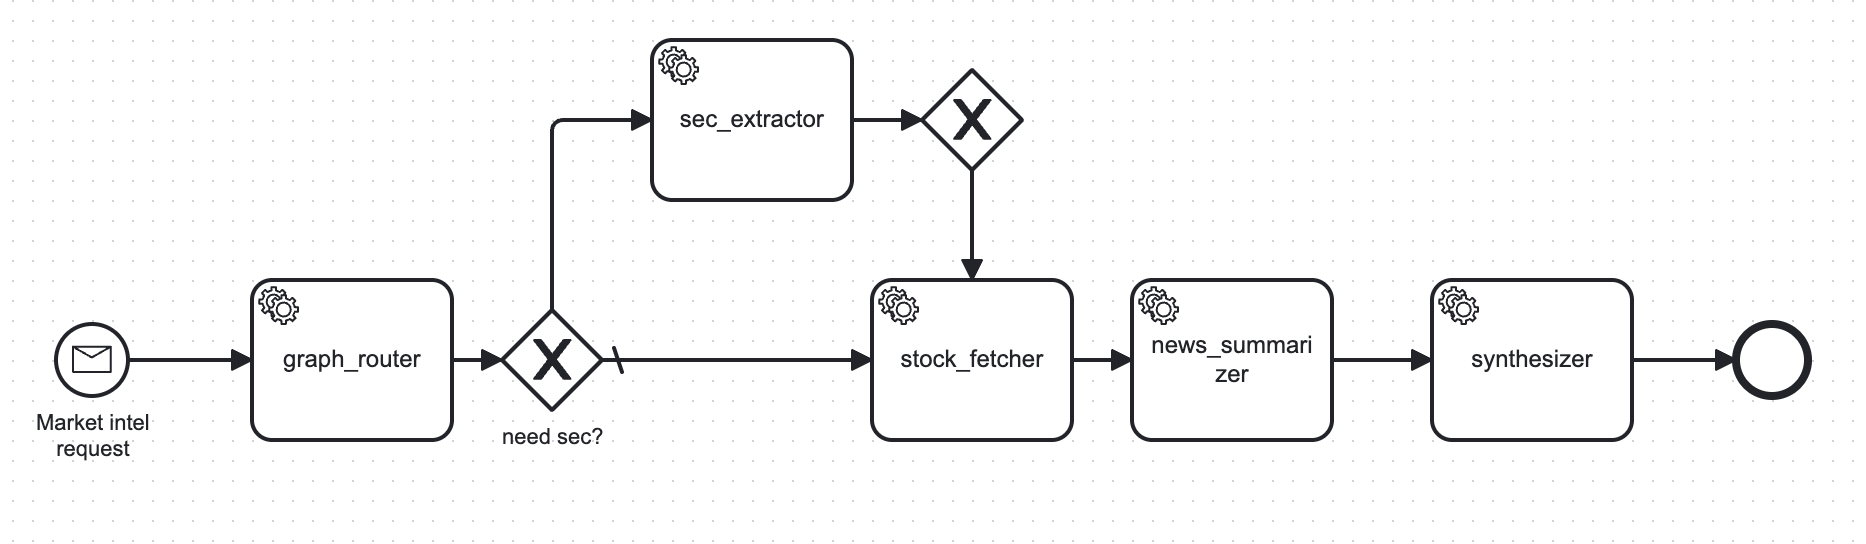

The diagram shows the flow for one invocation of the agent. Each activity (box) is a node in the graph. The edges from the graph are the arrows. Circles are initial and end events. Diamonds with X are X-or decision splits (when branching out) or merges (when branches come into it). Only the activities will show as entries in the event log.

## Event Log Summary
Load in the XES event log. Dump the start and end events. 

Looks as expected so far. 

In [39]:
import pm4py
import pmagent_util
from pm4py.objects.bpmn.importer import importer as bpmn_importer
from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments

log_xes = pm4py.read_xes('xeslogs/market_intel_agent_DEFAULT_trace.xes', return_legacy_log_object=True)
[ "start", pm4py.get_start_activities(log_xes), "end",  pm4py.get_end_activities(log_xes) ]

parsing log, completed traces ::   0%|          | 0/34 [00:00<?, ?it/s]

['start', {'graph_router': 34}, 'end', {'synthesizer': 34}]

## Bring into data frame

Bring XES into a Pandas dataframe. PM will need this.

In [2]:
df = pm4py.convert_to_dataframe(log_xes)
df

,concept:name,org:resource,time:timestamp,duration_s,trace_id,session_id,case:concept:name
0,graph_router,,2026-05-25 23:47:56.649000+00:00,1.200,becfdca21d81a1ef,6719150f-dba2-404d-9a96-434693c8f479,becfdca21d81a1ef
1,synthesizer,,2026-05-25 23:47:59.747000+00:00,3.098,becfdca21d81a1ef,6719150f-dba2-404d-9a96-434693c8f479,becfdca21d81a1ef
2,graph_router,,2026-05-25 23:44:11.494000+00:00,1.783,a58d15eb55641300,21bb86c8-3e5c-49bd-a0da-afa460db756a,a58d15eb55641300
3,sec_extractor,,2026-05-25 23:44:13.411000+00:00,1.916,a58d15eb55641300,21bb86c8-3e5c-49bd-a0da-afa460db756a,a58d15eb55641300
4,stock_fetcher,,2026-05-25 23:44:15.063000+00:00,1.652,a58d15eb55641300,21bb86c8-3e5c-49bd-a0da-afa460db756a,a58d15eb55641300
...,...,...,...,...,...,...,...
129,graph_router,,2026-05-25 23:45:55.695000+00:00,1.270,235d723da1b0b44d,9bcf8b63-43e0-43ac-8c76-ba4e68ba661d,235d723da1b0b44d
130,sec_extractor,,2026-05-25 23:45:57.915000+00:00,2.220,235d723da1b0b44d,9bcf8b63-43e0-43ac-8c76-ba4e68ba661d,235d723da1b0b44d
131,stock_fetcher,,2026-05-25 23:45:59.677000+00:00,1.761,235d723da1b0b44d,9bcf8b63-43e0-43ac-8c76-ba4e68ba661d,235d723da1b0b44d
132,news_summarizer,,2026-05-25 23:46:01.528000+00:00,1.851,235d723da1b0b44d,9bcf8b63-43e0-43ac-8c76-ba4e68ba661d,235d723da1b0b44d


How many total cases (or, in our case, conversational sessions) do we have? What are the most common variants (or tool paths taken) in these sessions?

The most common variants are mostly expected:

- *Happy path*: graph_router->sec_extractor->stock_fetcher->news_summarizer->synthesizer
- *Happy path with SEC skipped*: graph_router->sec_extractor->stock_fetcher->news_summarizer->synthesizer
- *Irrelevant path, a bit more cases than expected*: graph_router->synthesizer


In [28]:
variants=pm4py.get_variants(df, activity_key="concept:name", case_id_key="case:concept:name")
pmagent_util.dump_variants(df, variants)

Number of cases 34

Frequent variants
15 graph_router->stock_fetcher->news_summarizer->synthesizer
12 graph_router->sec_extractor->stock_fetcher->news_summarizer->synthesizer
7 graph_router->synthesizer

All variants
15 graph_router->stock_fetcher->news_summarizer->synthesizer
12 graph_router->sec_extractor->stock_fetcher->news_summarizer->synthesizer
7 graph_router->synthesizer

All variants, stutter removed
15 graph_router->stock_fetcher->news_summarizer->synthesizer
12 graph_router->sec_extractor->stock_fetcher->news_summarizer->synthesizer
7 graph_router->synthesizer


## Discovery

From the event log, discover the process. For comparison, bring in our intended model so it can be compared. Recall, we drew our intended model (shown above) as a BPMN process using bpmn.io open-source editor.

To discover the process, we use the inductive miner. The Inductive Miner uses a top-down, divide-and-conquer approach that recursively breaks the event log down into standard workflow structures: sequences, loops, exclusive-or (XOR) choices, and parallel paths. By default, it guarantees a mathematically sound model that fits all the cases in the log. However, to achieve this perfect fitness, it tends to overgeneralize, meaning it can create a model that is highly structured but occasionally too permissive. Fortunately, the algorithm can be configured to filter out infrequent variants and tolerate noise.

We visualize these models using both standard BPMN and the more academically focused Petri Net. We include Petri Nets because they are the foundational language of process mining theory, allowing us to mathematically demonstrate concurrency, states, and token-based playback.

*Finding*: Notice how similar the intended and discovered models are. The main difference is the irrelevant path that takes us directly from group_router to synthesizer. This path occurs when the user asks a question not related to market intelligence. Our intended model skips this path because it is considered too rare. Keep it simple!


Intended BPMN model


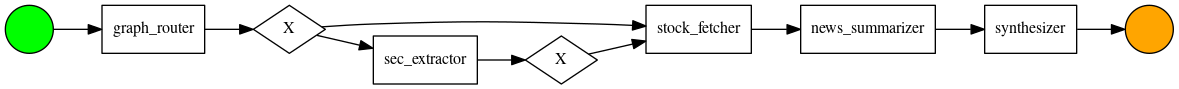

Discovered BPMN model


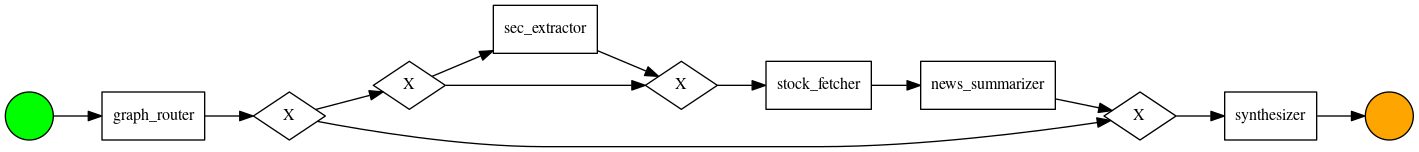

Intended Petri net


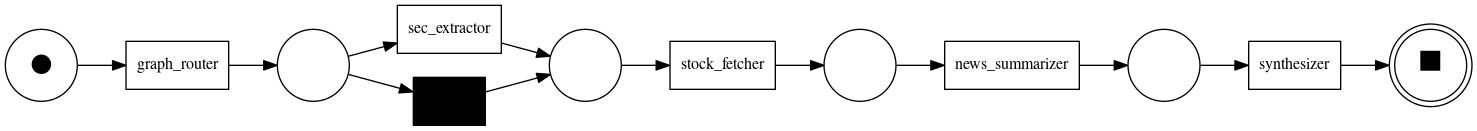

Discovered Petri net


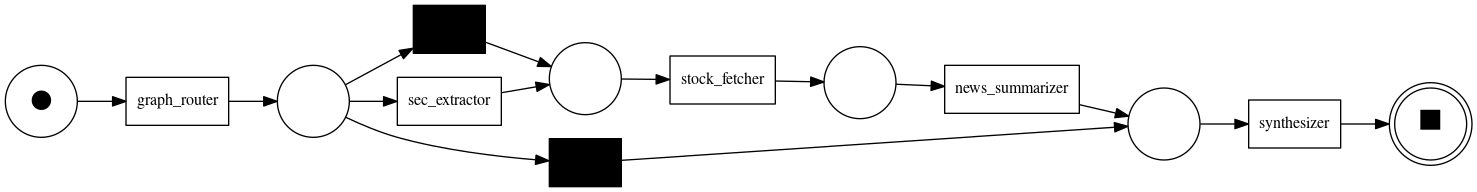

In [40]:
intended_bpmn_model = bpmn_importer.apply("../agents/market_intel_graph/intended_flow.bpmn")
intended_pn_net, intended_pn_im, intended_pn_fm = pm4py.convert_to_petri_net(intended_bpmn_model)

discovered_bpmn_model = pm4py.discover_bpmn_inductive(df)
disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm  = pm4py.discover_petri_net_inductive(df)

print("Intended BPMN model")
pm4py.view_bpmn(intended_bpmn_model)
print("Discovered BPMN model")
pm4py.view_bpmn(discovered_bpmn_model)
print("Intended Petri net")
pm4py.view_petri_net(intended_pn_net, intended_pn_im, intended_pn_fm)
print("Discovered Petri net")
pm4py.view_petri_net(disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm)


### Alternative Algorithms and Diagram Types

We try out a few additional mining algorithms. 

The first is to run inductive with "less noise". 

We also run the Heuristic Miner. The Inductive Miner uses a top-down approach that forces raw event logs into strict, mathematically sound structural blocks, which guarantees no deadlocks but often sacrifices precision by overgeneralizing allowable paths. In contrast, the Heuristic Miner takes a pragmatic, statistical approach based on frequency thresholds and activity dependencies, making it vastly superior at filtering out real-world noise and preserving precise agent paths. However, because the Heuristic Miner maps local dependencies instead of rigid global blocks, it does not guarantee a mathematically sound model, presenting a direct trade-off between structural perfection and practical diagnostic clarity.

We draw the Petri Nets for both. As it turns out, they look the same as the inductively discovered Petri Net above. 


Discovered Petri net - less noise


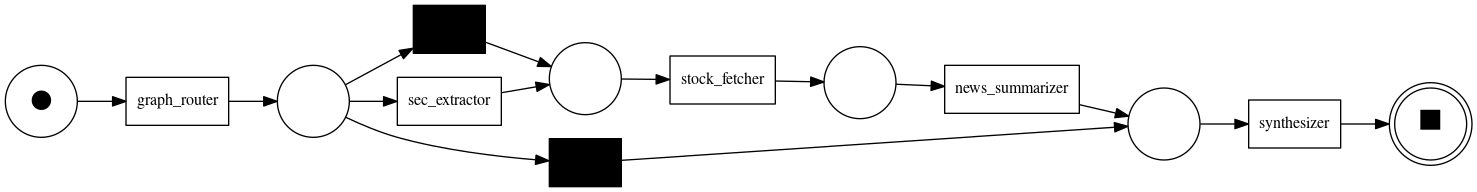

Discovered Petri net - heuristic


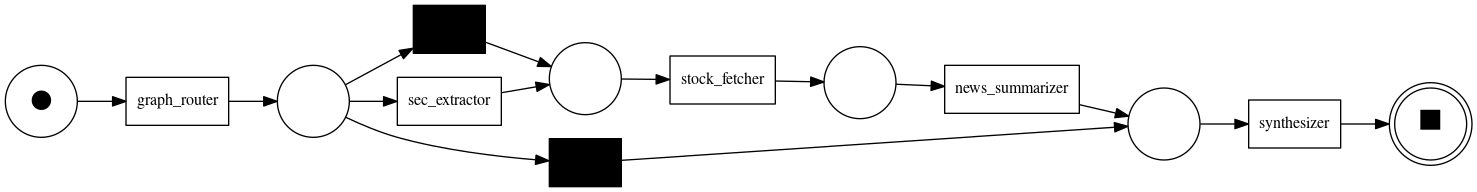

In [44]:
less_noise_param=0.8
disc_pn_ind_quiet_net, disc_pn_ind_quiet_im, disc_pn_ind_quiet_fm  = pm4py.discover_petri_net_inductive(df, less_noise_param)
disc_pn_heu_net, disc_pn_heu_im, disc_pn_heu_fm  = pm4py.discover_petri_net_heuristics(df)

print("Discovered Petri net - less noise")
pm4py.view_petri_net(disc_pn_ind_quiet_net, disc_pn_ind_quiet_im, disc_pn_ind_quiet_fm)
print("Discovered Petri net - heuristic")
pm4py.view_petri_net(disc_pn_heu_net, disc_pn_heu_im, disc_pn_heu_fm)


We also draw some alternative representions.

A Process Tree is a hierarchical, block-structured representation of a workflow that models execution logic as a mathematical tree rather than a free-form graph. It has no loops and will never look like spaghetti. For this agent, the inductive Petri Net was clear enough, so the process tree representation doesn't add much clarity.

Read it from left to right. As you move in that direction, you encounter several levels of tree. For each level, read top to bottom. 

At the far left, we see this tree starts as a sequence ("seq"). 

Moving right to the next level, we see that the sequence is graph_router, then an XOR, then synthesizer. 

Moving right to the next level, we see that XOR from the previous level either just stops (the small black dot) or enters into another sequence.

Moving right to the next level, the sequence consists of another XOR followed by stock_fetcher and then news_summarizer.

Finally in the last level at the far right, we see that the previous XOR leads either to the end (small black dot) or sec_extractor.

The tree depicts exactly the flow we understood from above, just in a different representation. For example, we can see the happy path by traversing the following paths through the tree. Follow along!

seq -> graph router
seq -> xor-> seq-> xor-> sec_extractor
seq -> xor -> seq -> stock_fetcher
seq -> xor -> seq -> news_summarizer
seq -> synthesizer


Process tree


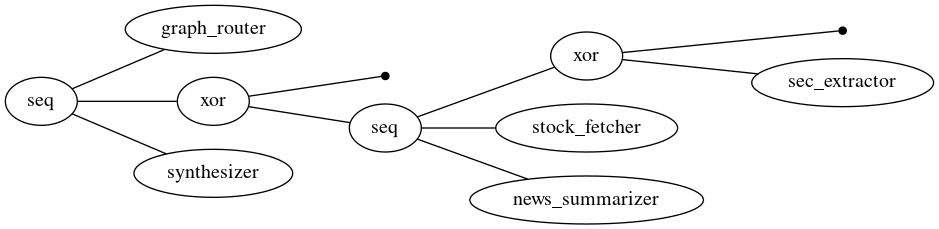

In [46]:
process_tree = pm4py.discover_process_tree_inductive(df)
print("Process tree")
pm4py.view_process_tree(process_tree)

Next, we draw a Directly-Follows Graph (DFG). DFG  is not a process model. Rather it shows how one activity directly follows another in the log. It's useful if I want to focus on just that. For this agent, the inductively-discovered process was clear, so we are less interested in DFG. (In messy logs, the DFG can tend to look like spaghetti.)

Here is how to read it.

Each box is an activity. The number in parentheses is a count of cases in which that activity occurred. Color is indicative of *heat*. Darker boxes represent more-frequent activities.

An arrow connects a pair of activities, showing that one activity *directly follows* another. The number on the arrow is the frequency, or number of times, that relationship is seen in the event log. Thick lines are more frequently-observed follows relationships.

Follow only with the DFG for this agent. It shows the following directly-follows relationships:

- The start of the case (big circle at the far left) and graph_router
- graph_router and sec_extractor
- graph_router and stock_fetcher
- graph_router and synthesizer
- sec_extractor and stock_fetcher
- stock_fetcher and news_summarizer
- synthesizer and end of the case (big circle at the far right)


Directly-Follows Graph (DFG)


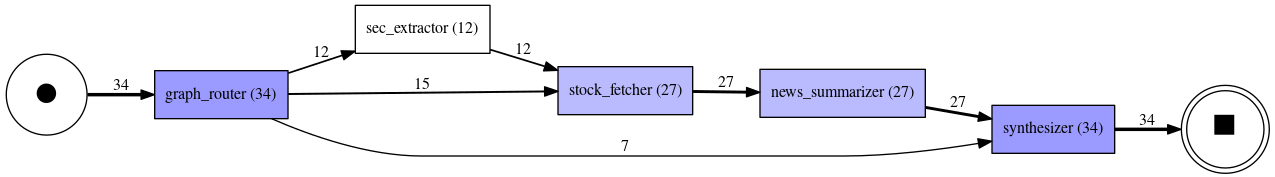

In [48]:
dfg, start_activities, end_activities = pm4py.discover_dfg(df)
print("Directly-Follows Graph (DFG)")
pm4py.view_dfg(dfg, start_activities, end_activities)


Next is a Heuristics Net. It is produced by the Heuristics Miner from above. It is like a DFG but filters out noise and can detect concurrency. For this agent, the heuristics net look resembles the DFG. Take a look and follow along with it; it is intuitive. 

For this agent, because the inductive Petri Net told the story so well, we rely less on the heuristics net. 

Heuristic net


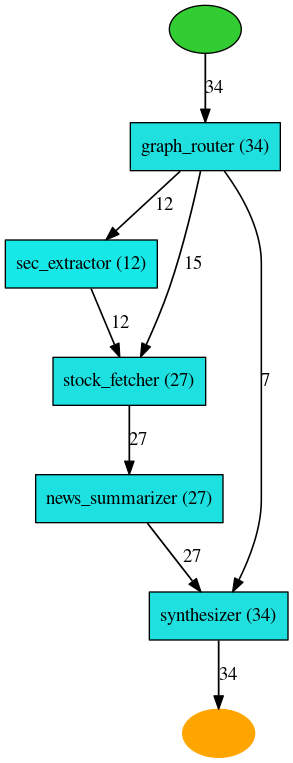

In [49]:
map=pm4py.discover_heuristics_net(df)
print("Heuristic net")
pm4py.view_heuristics_net(map)


Finally Footprints is a matrix of activities. It shows how each activity structurally related to each other activity. 

Example: graph_router and news_summarizer. Start in the row for graph_router and check the news_summarizer column. The cell contains a #, meaning that there is no directly follows relationship between these activities.

Example: sec_extractor and stock_fetcher. Start in the row for sec_extractor and check the stock_fetcher column, The cell contains a > meaning that sec_extractor comes before stock_fetcher in a directly-follows relationship.

Although great for structural relationships, the Footprints matrix does not show frequency (or how often the relationship was observed). It also does not handle noise.

For the current agent, this matrix representation is less useful because the inductively discovered process tells the story.  


Footprints


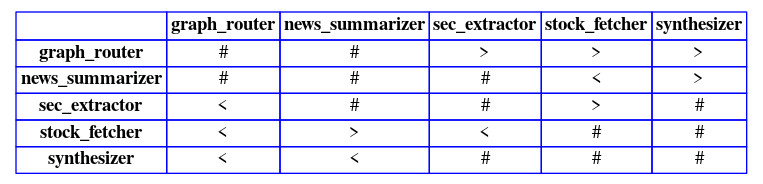

In [50]:
footprints = pm4py.discover_footprints(df)
print("Footprints")
pm4py.view_footprints(footprints)

## Conformance

Now we use pm4py conformance tools to assess how well the event log aligns with our intended model. We compare that to the discovered model. 

We will use two ways to measure conformance: 
- *Token-based replay*: An execution audit that replays the event log traces through the Petri net step-by-step. Petri Nets are all about passing tokens through the net! Token-based replay tracks compliance by counting "tokens" that are correctly consumed, missing (required but unavailable), or stranded (left over at execution end).
- *Alignment*: A cost-optimal synchronization method that maps the event log (Reality) directly against the model paths (Intent). It explicitly pairs actions into synchronous moves, moves on log (unintended agent drift), or moves on model (skipped architectural steps), revealing the exact point of divergence.

For each we measure fitness and precision. We do this for both the discovered model and the intended model. 

- *Fitness* is the degree to which the event log traces can be successfully replayed by the model. High fitness means the architecture successfully accounts for all the tool paths and edge cases the agent actually executed in production.
- *Precision* is the degree to which the model restricts behavior not seen in the log. High precision means the architecture tightly constrains the agent, preventing it from wandering into unprescribed tool loops or "off-road" states that never occurred in reality.

We also visualize issues caught during conformance.

Here is what we expect to find:
- The discovered model will have 100 percent fitness because the Inductive Miner constructs the process tree specifically to explain and fit every case in the event log.
- The intended model will have high but not perfect fitness because, as we saw above, it does fit all variants.
- The discovered model will have lower precision because, in order to guarantee absolute fitness and mathematical soundness, the inductive algorithm overgeneralizes, introducing allowable structural paths that were never actually visited by cases.
- The intended model is very precise because it is designed to strictly limit execution to a limited set of paths.


### Token-based

As expected, the discovered model has 100 percent fitness. 

The intended model has 79.4 percent fitness, probably because of the "irrelevanve" variant; we will check that in a moment. Here focus on perc_fit_traces.

Both discovered and intended models have perfect precision. For the discovered model, we hadn't bet on this. It can be explained by the lack of noise in the event log.

In [51]:
for s in [ 
    "\nintended fitness (token-based replay)", 
    pm4py.fitness_token_based_replay(df, intended_pn_net,intended_pn_im,intended_pn_fm),
    "\ndiscovered fitness (token-based replay)",
    pm4py.fitness_token_based_replay(df, disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm ),
    "\nintended precision (token-based replay)",
    pm4py.precision_token_based_replay(df, intended_pn_net,intended_pn_im,intended_pn_fm),
    "\ndiscovered precision (token-based replay)",
    pm4py.precision_token_based_replay(df, disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm )
]:
    print(s)

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/6 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/6 [00:00<?, ?it/s]


intended fitness (token-based replay)
{'perc_fit_traces': 79.41176470588235, 'average_trace_fitness': 0.9313725490196079, 'log_fitness': 0.9617486338797814, 'percentage_of_fitting_traces': 79.41176470588235}

discovered fitness (token-based replay)
{'perc_fit_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 1.0, 'percentage_of_fitting_traces': 100.0}

intended precision (token-based replay)
1.0

discovered precision (token-based replay)
1.0


Next, let's gather diagnostics for the token-based replay to see why the intended model's fitness was less than 100 percent.

it is indeed the graph_router->synthesizer "irrelevance" variant.

In [52]:
tbr_results = pm4py.conformance_diagnostics_token_based_replay(df, intended_pn_net,intended_pn_im,intended_pn_fm)
pmagent_util.dump_conformance_diagnostics(df, tbr_results, "token")


replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

=== NON-COMPLIANT AGENT TRACE AUDIT (TOKEN METHOD) ===
Found 1 distinct non-compliance patterns:

⚠️  Pattern Detected: 7 occurrences
   Impacted Case IDs: [ce395585264e5b98, c68a4a37dfefdc7a, ac7f7af2cbb8bec7 ... (+4 more)]
   Discovered Variant: graph_router->synthesizer
   Compliance Issue: The agent broke sequence rules. It attempted to execute 
                     'synthesizer' before prerequisite phase gates opened/closed.
   Replay Metrics:     Missing Tokens: 1 | Stranded Tokens: 1

--------------------------------------------------------------------------------



### Alignments

We do similar checks on fitness and precision using alignments. The numbers are similar to token-based because both methods are evaluating the exact same underlying reality—the interplay between the log's traces and the model's paths—just using different mathematical lenses.

When the event log is clean, as for this agent, the metrics will naturally converge on nearly identical scores.

In [53]:
for s in [ 
    "\nintended fitness (alignments)", 
    pm4py.fitness_alignments(df, intended_pn_net,intended_pn_im,intended_pn_fm),
    "\ndiscovered fitness (alignments)",
    pm4py.fitness_alignments(df, disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm ),
    "\nintended precision (alignments)",
    pm4py.precision_alignments(df, intended_pn_net,intended_pn_im,intended_pn_fm),
    "\ndiscovered precision (alignments)",
    pm4py.precision_alignments(df, disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm )
]:
    print(s)

pm4py.fitness_alignments(df, intended_pn_net,intended_pn_im,intended_pn_fm)

aligning log, completed variants ::   0%|          | 0/3 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/3 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/6 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/6 [00:00<?, ?it/s]


intended fitness (alignments)
{'percFitTraces': 79.41176470588235, 'averageFitness': 0.9313725490196081, 'percentage_of_fitting_traces': 79.41176470588235, 'average_trace_fitness': 0.9313725490196081, 'log_fitness': 0.9481406530436284}

discovered fitness (alignments)
{'percFitTraces': 100.0, 'averageFitness': 1.0, 'percentage_of_fitting_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 0.9999891090942034}

intended precision (alignments)
1.0

discovered precision (alignments)
1.0


aligning log, completed variants ::   0%|          | 0/3 [00:00<?, ?it/s]

{'percFitTraces': 79.41176470588235,
 'averageFitness': 0.9313725490196081,
 'percentage_of_fitting_traces': 79.41176470588235,
 'average_trace_fitness': 0.9313725490196081,
 'log_fitness': 0.9481406530436284}

Run diagnostics on the fitness of the intended model.

In [57]:
aln_results = pm4py.conformance_diagnostics_alignments(df, intended_pn_net,intended_pn_im,intended_pn_fm)
pmagent_util.dump_conformance_diagnostics(df, aln_results, "alignment")


aligning log, completed variants ::   0%|          | 0/3 [00:00<?, ?it/s]

=== NON-COMPLIANT AGENT TRACE AUDIT (ALIGNMENT METHOD) ===
Found 1 distinct non-compliance patterns:

⚠️  Pattern Detected: 7 occurrences
   Impacted Case IDs: [ce395585264e5b98, c68a4a37dfefdc7a, ac7f7af2cbb8bec7 ... (+4 more)]
   [ VISUAL ALIGNMENT LADDER ]
       Log (Reality):   [ graph_router | >>   | >>            | >>              | synthesizer ]
                            |             ▼ SKIP   ▼ SKIP          ▼ SKIP             |         
       Model (Intent):  [ graph_router | None | stock_fetcher | news_summarizer | synthesizer ]

   Alignment Metrics:  Fitness Score: 0.67 | Total Alignment Cost: 20001

--------------------------------------------------------------------------------



Finally, we can visualize at the intended model (as Petri Net) with alignment issues indicated. 

In each box are two numbers. The first is the number of deviations. The second is the total number of occurrences. Box color represents deviation "heat".  

aligning log, completed variants ::   0%|          | 0/3 [00:00<?, ?it/s]

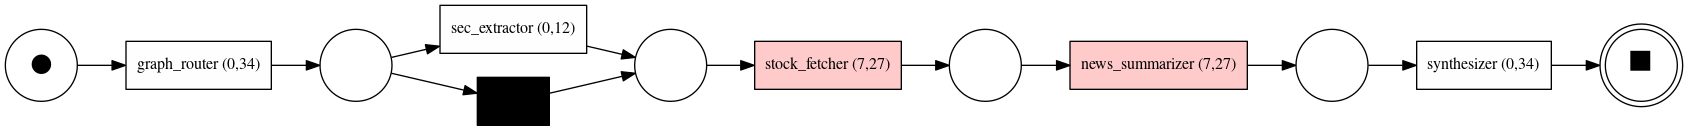

In [58]:
from pm4py.visualization.petri_net import visualizer as pn_visualizer
gviz = pn_visualizer.apply(intended_pn_net,intended_pn_im,intended_pn_fm,
                           log=df, variant=pn_visualizer.Variants.ALIGNMENTS)
pn_visualizer.view(gviz)


## Findings and Recommendations
Our agent is implemented as a graph, so the path it follows during execution is bound by that graph model. When we represent that graph as a process model, we find that it scores high on fitness and precision.

All process models, even ones with strict flow, are subject to drift. We found one variant, the "irrelevance" path. Next step is a choice:

- Shall we consider this variant a first-class path in the process flow? Then re-reun the miner with an intended model that includes this variant. Redraw the model beforehand.
- Revisit the agent to reduce occurrences of this variant. Maybe the agent should filter out these cases before entering entering it's agentic graph in the first place.
  